In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Fetch dataset
diabetes = fetch_ucirepo(id=296)
df = diabetes.data.original


df.to_csv('hospital_readmission_raw.csv', index=False)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Shape: (101766, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [ ]:

import pandas as pd

df = pd.read_csv('hospital_readmission_raw.csv')

df.replace('?', pd.NA, inplace=True)

missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

print(summary[summary['Missing Count'] > 0])

/tmp/ipykernel_705/2151921166.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('hospital_readmission_raw.csv')


                   Missing Count  Missing %
race                        2273       2.23
weight                     98569      96.86
payer_code                 40256      39.56
medical_specialty          49949      49.08
diag_1                        21       0.02
diag_2                       358       0.35
diag_3                      1423       1.40
max_glu_serum              96420      94.75
A1Cresult                  84748      83.28


In [ ]:
import pandas as pd

df = pd.read_csv('hospital_readmission_raw.csv', low_memory=False)

df.replace('?', pd.NA, inplace=True)

df.drop(columns=['weight', 'max_glu_serum', 'A1Cresult', 'payer_code'], inplace=True)


df['race'].fillna('Unknown', inplace=True)
df['medical_specialty'].fillna('Unknown', inplace=True)

df['diag_2'].fillna('None', inplace=True)
df['diag_3'].fillna('None', inplace=True)

df.dropna(subset=['diag_1'], inplace=True)

print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nDataset shape: {df.shape}")

df.to_csv('hospital_readmission_clean.csv', index=False)
print("\nClean file save ho gayi!")

/tmp/ipykernel_705/2800116403.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['race'].fillna('Unknown', inplace=True)
/tmp/ipykernel_705/2800116403.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

Remaining missing values:
Series([], dtype: int64)

Dataset shape: (101745, 46)

Clean file save ho gayi!


In [ ]:
import sqlite3

#data sorce lode
df = pd.read_csv('hospital_readmission_clean.csv', low_memory=False)

# SQLite database create
conn = sqlite3.connect('hospital.db')

# table create and insert data
df.to_sql('patients', conn, if_exists='replace', index=False)

print("Database ready!")
print(f"Total rows: {len(df)}")

show = pd.read_sql("SELECT * FROM patients LIMIT 5", conn)
print(show.head())

Database ready!
Total rows: 101745
   encounter_id  patient_nbr             race  gender      age  \
0       2278392      8222157        Caucasian  Female   [0-10)   
1        149190     55629189        Caucasian  Female  [10-20)   
2         64410     86047875  AfricanAmerican  Female  [20-30)   
3        500364     82442376        Caucasian    Male  [30-40)   
4         16680     42519267        Caucasian    Male  [40-50)   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital         medical_specialty  ...  citoglipton  insulin  \
0                 1  Pediatrics-Endocrinology  ...           No  

In [ ]:
q1 = pd.read_sql("""
    SELECT
        readmitted,
        COUNT(*) as total_patients,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM patients), 2) as percentage
    FROM patients
    GROUP BY readmitted
    ORDER BY total_patients DESC
""", conn)

print("Readmission Overview:")
print(q1)

Readmission Overview:
  readmitted  total_patients  percentage
0         NO           54852       53.91
1        >30           35541       34.93
2        <30           11352       11.16


In [ ]:
import pandas as pd
q2 = pd.read_sql("""
    SELECT
        age,
        COUNT(*) as total,
        SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) as readmitted_30,
        ROUND(SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as readmission_rate
    FROM patients
    GROUP BY age
    ORDER BY age
""", conn)

print(" Age Group wise Readmission:")
print(q2)

 Age Group wise Readmission:
        age  total  readmitted_30  readmission_rate
0    [0-10)    161              3              1.86
1   [10-20)    691             40              5.79
2   [20-30)   1656            236             14.25
3   [30-40)   3775            424             11.23
4   [40-50)   9683           1026             10.60
5   [50-60)  17254           1668              9.67
6   [60-70)  22476           2501             11.13
7   [70-80)  26064           3068             11.77
8   [80-90)  17192           2076             12.08
9  [90-100)   2793            310             11.10


In [ ]:
q3 = pd.read_sql("""
    SELECT
        diag_1,
        COUNT(*) as total_cases,
        SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) as readmitted_30,
        ROUND(SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as readmission_rate
    FROM patients
    GROUP BY diag_1
    HAVING total_cases > 100
    ORDER BY readmission_rate DESC
    LIMIT 10
""", conn)

print(" Top 10 High Risk Diagnoses:")
print(q3)

 Top 10 High Risk Diagnoses:
  diag_1  total_cases  readmitted_30  readmission_rate
0    V58          228             95             41.67
1    443          110             24             21.82
2    593          101             21             20.79
3    572          239             49             20.50
4    202          104             20             19.23
5  250.7          871            165             18.94
6    790          144             27             18.75
7  250.6         1183            219             18.51
8    787          267             49             18.35
9    707          257             43             16.73


In [ ]:
q4 = pd.read_sql("""
    SELECT
        gender,
        COUNT(*) as total,
        ROUND(AVG(num_medications), 2) as avg_medications,
        ROUND(AVG(time_in_hospital), 2) as avg_hospital_days,
        SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) as readmitted_30
    FROM patients
    WHERE gender != 'Unknown'
    GROUP BY gender
""", conn)

print("Gender wise Stats:")
print(q4)

Gender wise Stats:
            gender  total  avg_medications  avg_hospital_days  readmitted_30
0           Female  54703            16.19               4.48           6151
1             Male  47039            15.83               4.30           5201
2  Unknown/Invalid      3            16.33               3.33              0


In [ ]:
q5 = pd.read_sql("""
    SELECT
        CASE
            WHEN num_medications <= 5 THEN '1-5 medicines'
            WHEN num_medications <= 10 THEN '6-10 medicines'
            WHEN num_medications <= 15 THEN '11-15 medicines'
            ELSE '16+ medicines'
        END as medication_group,
        COUNT(*) as total,
        ROUND(SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as readmission_rate
    FROM patients
    GROUP BY medication_group
    ORDER BY readmission_rate DESC
""", conn)

print("Medication Count vs Readmission:")
print(q5)

Medication Count vs Readmission:
  medication_group  total  readmission_rate
0    16+ medicines  46514             12.48
1  11-15 medicines  29377             10.91
2   6-10 medicines  20790              9.45
3    1-5 medicines   5064              7.48


In [ ]:
# Q6 — FIXED
q6 = pd.read_sql("""
    SELECT
        time_in_hospital,
        COUNT(*) as total_patients,
        ROUND(SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as readmission_rate
    FROM patients
    GROUP BY time_in_hospital
    ORDER BY time_in_hospital
""", conn)

print("Hospital Stay Duration vs Readmission:")
print(q6)

Hospital Stay Duration vs Readmission:
    time_in_hospital  total_patients  readmission_rate
0                  1           14206              8.18
1                  2           17223              9.94
2                  3           17750             10.66
3                  4           13917             11.79
4                  5            9965             12.03
5                  6            7537             12.58
6                  7            5858             12.84
7                  8            4390             14.24
8                  9            3002             13.72
9                 10            2342             14.35
10                11            1855             10.51
11                12            1448             13.33
12                13            1210             12.31
13                14            1042             12.96


In [ ]:
q7 = pd.read_sql("""
    SELECT
        race,
        COUNT(*) as total,
        ROUND(SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as readmission_rate,
        READMITTED
    FROM patients
    WHERE race != 'Unknown'
    GROUP BY race
    ORDER BY readmission_rate DESC
""", conn)

print("Race wise Readmission Rate:")
print(q7)

Race wise Readmission Rate:
              race  total  readmission_rate readmitted
0        Caucasian  76092             11.29         NO
1  AfricanAmerican  19201             11.22         NO
2         Hispanic   2035             10.32        <30
3            Asian    640             10.16         NO
4            Other   1506              9.63         NO


In [ ]:
q8 = pd.read_sql("""
    SELECT
        patient_nbr,
        age,
        race,
        time_in_hospital,
        num_medications,
        number_diagnoses,
        readmitted
    FROM patients
    WHERE
        readmitted = '<30'
        AND num_medications > 15
        AND time_in_hospital > 7
        AND number_diagnoses > 5
    ORDER BY num_medications DESC
    LIMIT 20
""", conn)

print(" Top High Risk Patients:")
print(q8)

 Top High Risk Patients:
    patient_nbr      age             race  time_in_hospital  num_medications  \
0      24189597  [60-70)        Caucasian                10               81   
1      42522309  [70-80)        Caucasian                13               72   
2      42147990  [70-80)        Caucasian                14               72   
3      43515927  [60-70)        Caucasian                11               72   
4      25162767  [50-60)  AfricanAmerican                11               70   
5      23283081  [40-50)        Caucasian                 8               68   
6      41720949  [50-60)        Caucasian                 9               68   
7      23438790  [50-60)        Caucasian                10               67   
8      44517078  [60-70)        Caucasian                 8               67   
9      42161742  [40-50)        Caucasian                14               64   
10     43356447  [60-70)        Caucasian                11               63   
11     63125073

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Clean data load
df = pd.read_csv('hospital_readmission_clean.csv', low_memory=False)

# Plot style set
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150

print("Shape:", df.shape)
print(df['readmitted'].value_counts())

Shape: (101745, 46)
readmitted
NO     54852
>30    35541
<30    11352
Name: count, dtype: int64


In [ ]:
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print("Target distribution:")
print(df['readmitted_binary'].value_counts())
print(f"\nReadmission rate: {df['readmitted_binary'].mean()*100:.2f}%")

# Save
df.to_csv('hospital_readmission_clean.csv', index=False)

Target distribution:
readmitted_binary
0    90393
1    11352
Name: count, dtype: int64

Readmission rate: 11.16%


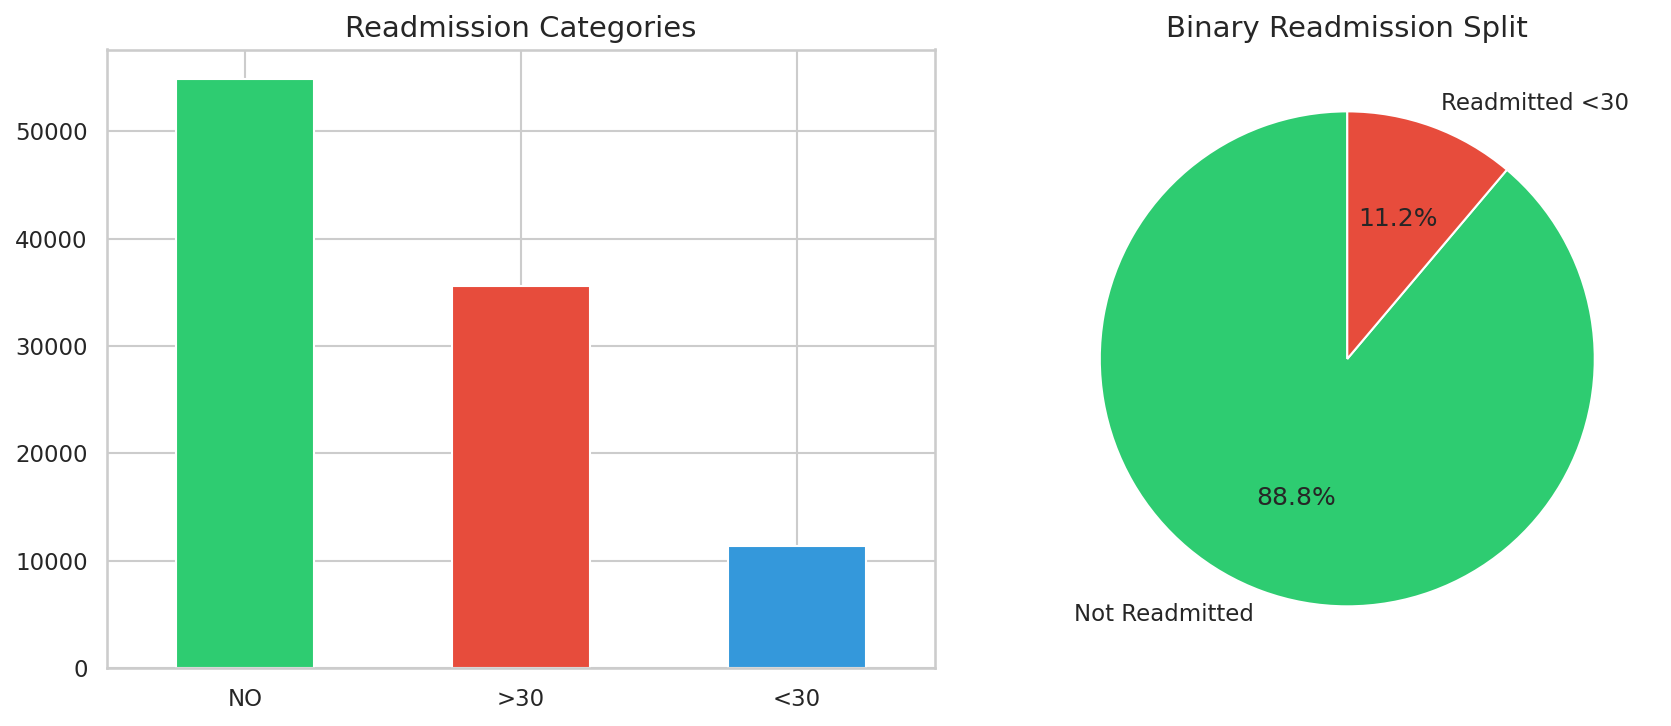

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: 3 categories
df['readmitted'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c', '#3498db'],
    edgecolor='white'
)
axes[0].set_title('Readmission Categories', fontsize=14)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Right: Binary
df['readmitted_binary'].value_counts().plot(
    kind='pie', ax=axes[1],
    labels=['Not Readmitted', 'Readmitted <30'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Binary Readmission Split', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('chart1_readmission_overview.png', bbox_inches='tight')
plt.show()

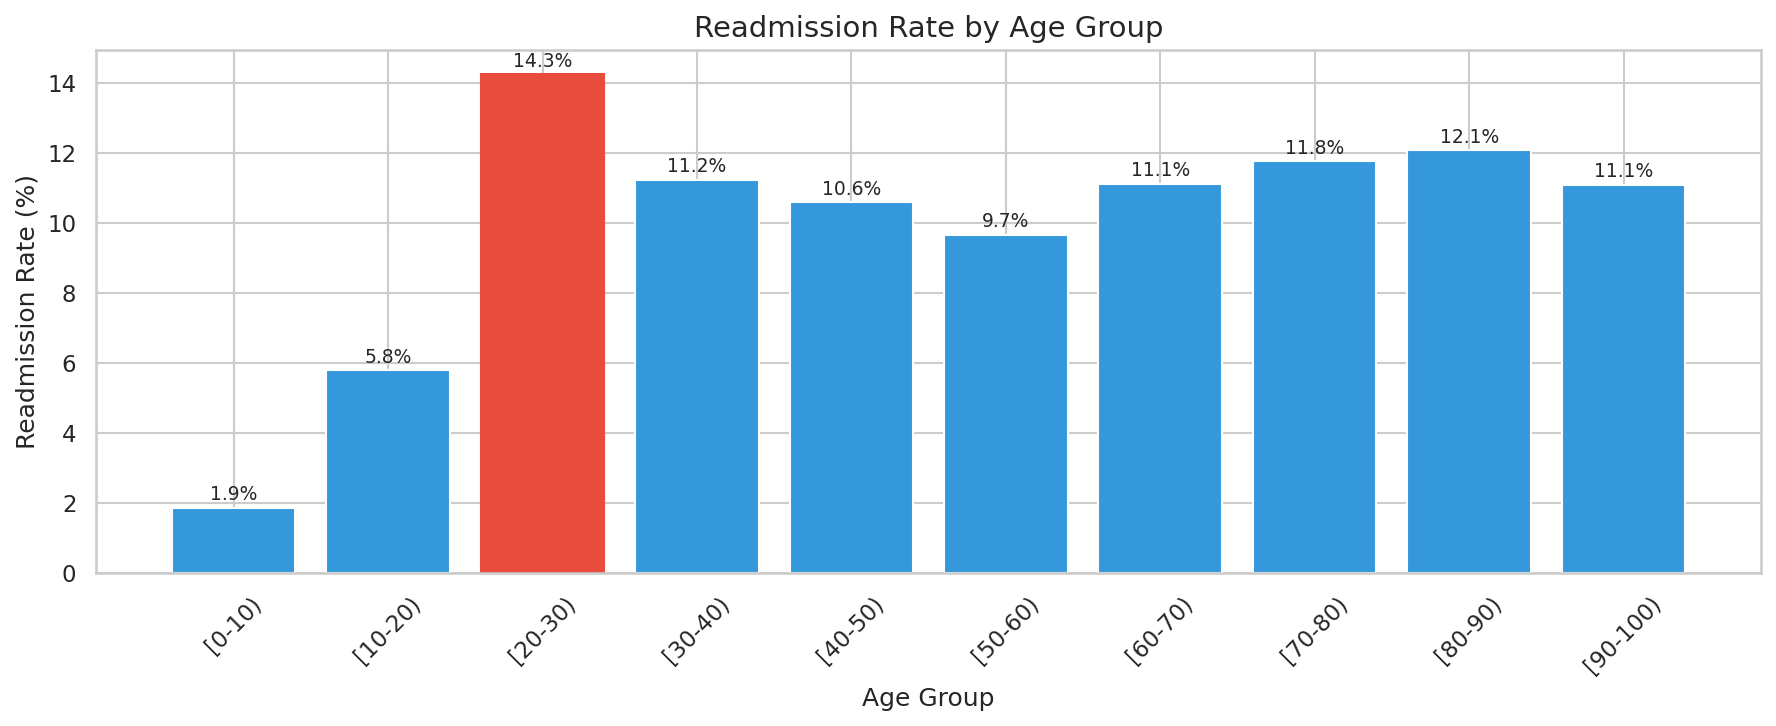

In [ ]:
age_stats = df.groupby('age')['readmitted_binary'].mean() * 100
age_stats = age_stats.reset_index()
age_stats.columns = ['age', 'readmission_rate']

plt.figure(figsize=(12, 5))
bars = plt.bar(age_stats['age'], age_stats['readmission_rate'],
               color='#3498db', edgecolor='white')

# Sabse high bar highlight karo
max_idx = age_stats['readmission_rate'].idxmax()
bars[max_idx].set_color('#e74c3c')

plt.title('Readmission Rate by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)

for bar, val in zip(bars, age_stats['readmission_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('chart2_age_readmission.png', bbox_inches='tight')
plt.show()

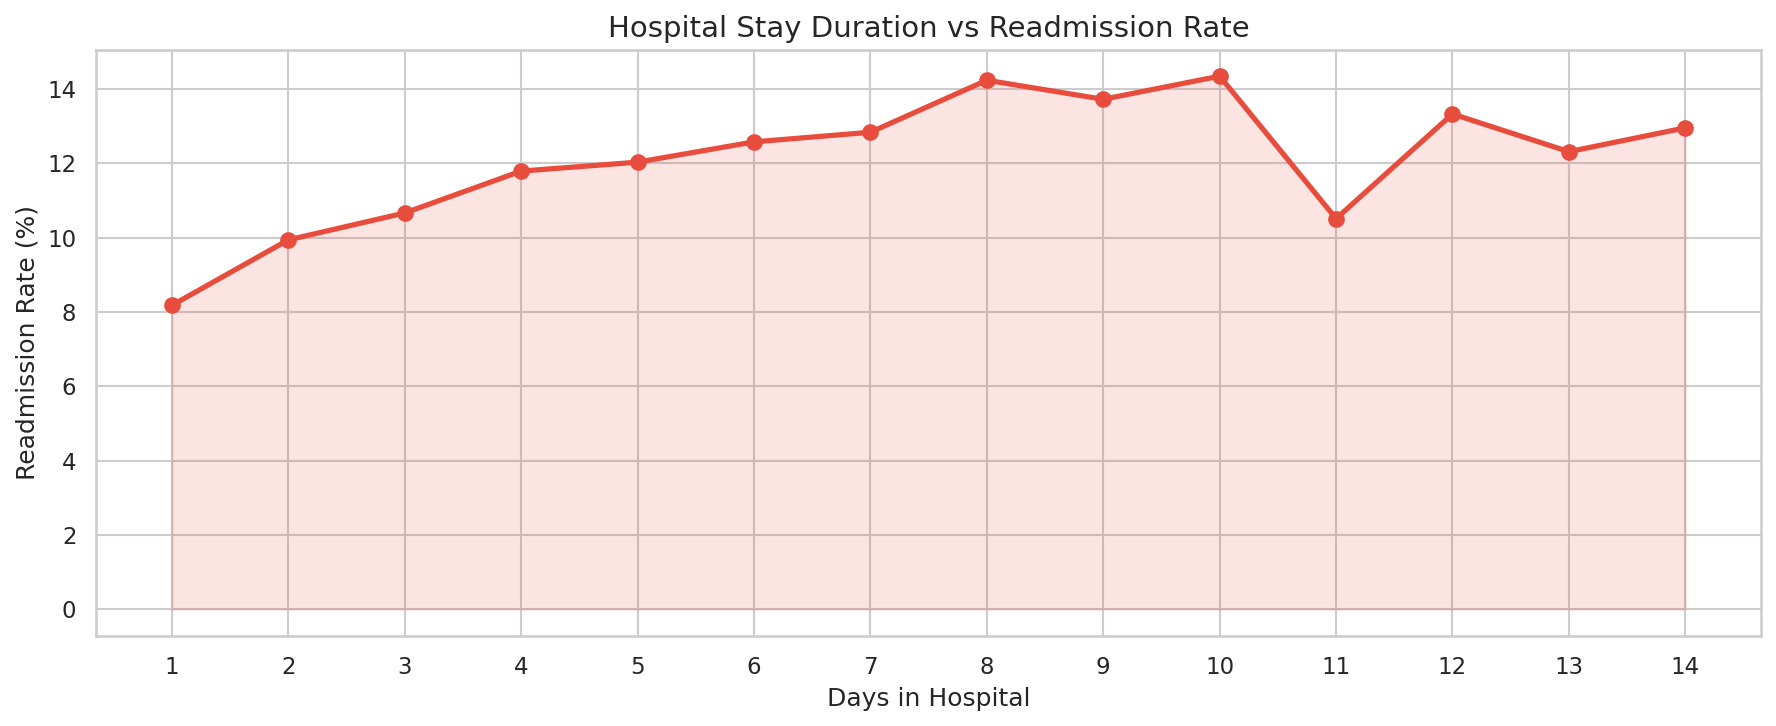

In [ ]:
stay_stats = df.groupby('time_in_hospital')['readmitted_binary'].mean() * 100

plt.figure(figsize=(12, 5))
plt.plot(stay_stats.index, stay_stats.values,
         marker='o', color='#e74c3c', linewidth=2.5, markersize=7)
plt.fill_between(stay_stats.index, stay_stats.values, alpha=0.15, color='#e74c3c')

plt.title('Hospital Stay Duration vs Readmission Rate', fontsize=14)
plt.xlabel('Days in Hospital')
plt.ylabel('Readmission Rate (%)')
plt.xticks(stay_stats.index)

plt.tight_layout()
plt.savefig('chart3_hospital_stay.png', bbox_inches='tight')
plt.show()

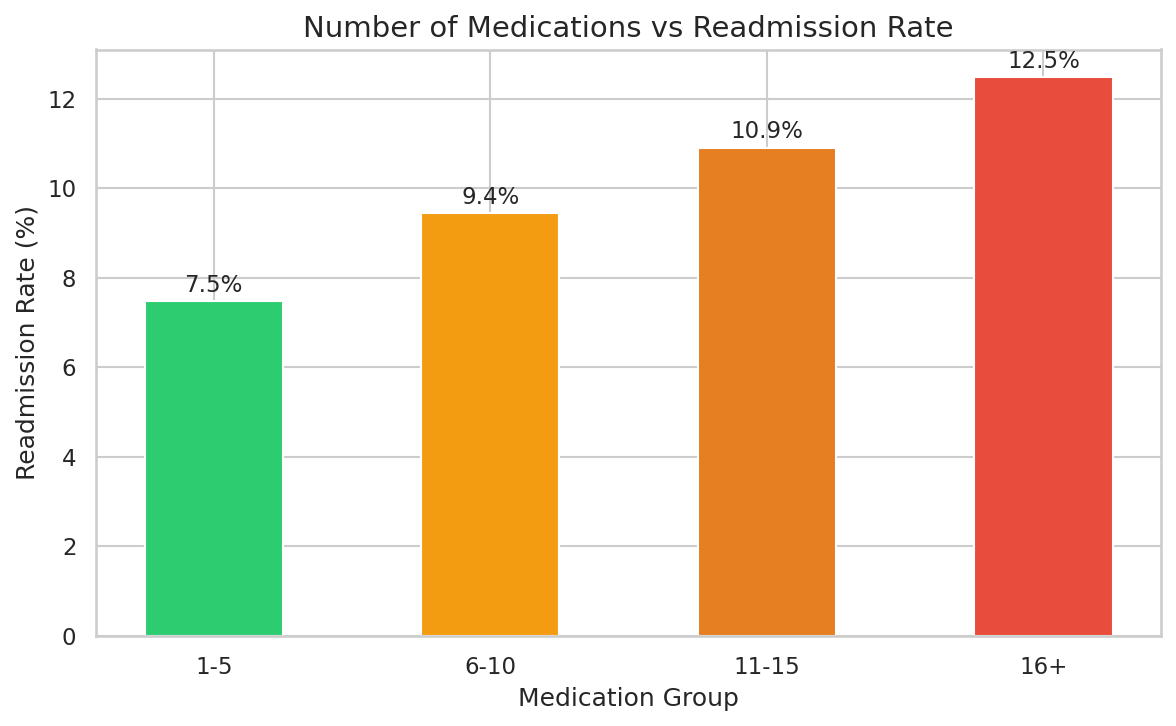

In [ ]:
df['med_group'] = pd.cut(df['num_medications'],
                          bins=[0, 5, 10, 15, 100],
                          labels=['1-5', '6-10', '11-15', '16+'])

med_stats = df.groupby('med_group', observed=True)['readmitted_binary'].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(med_stats.index, med_stats.values,
               color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'],
               edgecolor='white', width=0.5)

plt.title('Number of Medications vs Readmission Rate', fontsize=14)
plt.xlabel('Medication Group')
plt.ylabel('Readmission Rate (%)')

for bar, val in zip(bars, med_stats.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('chart4_medications.png', bbox_inches='tight')
plt.show()

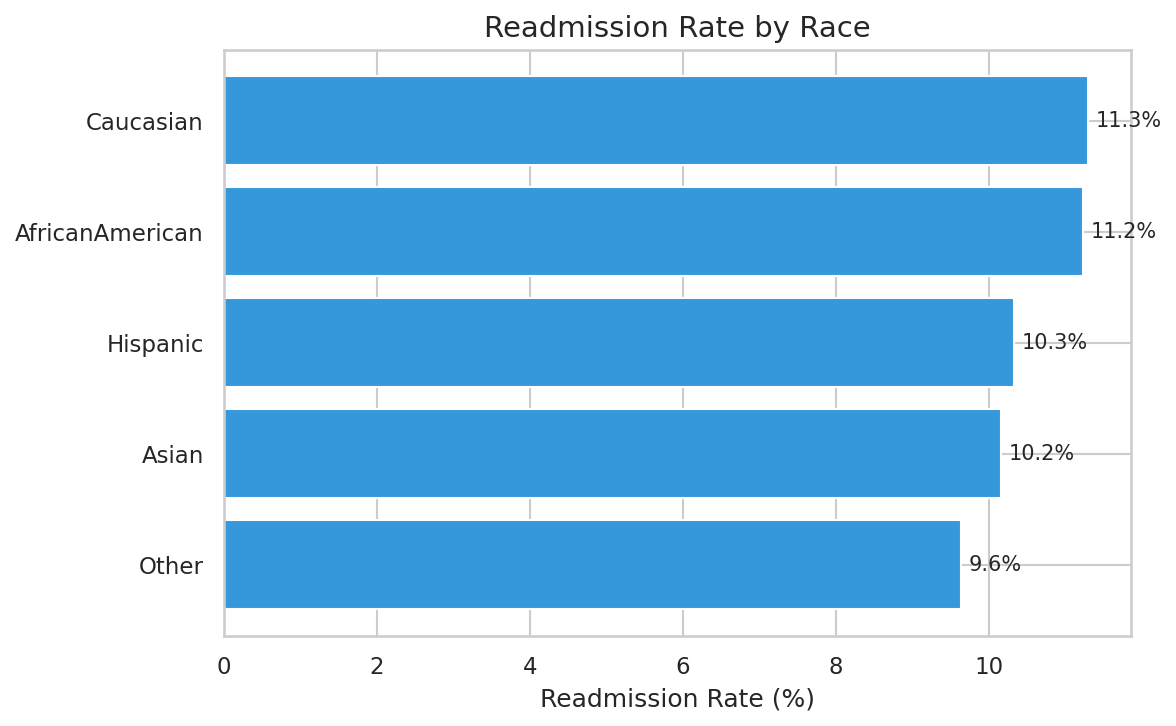

In [ ]:
race_stats = df[df['race'] != 'Unknown'].groupby('race')['readmitted_binary'].mean() * 100
race_stats = race_stats.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(race_stats.index, race_stats.values,
                color='#3498db', edgecolor='white')

plt.title('Readmission Rate by Race', fontsize=14)
plt.xlabel('Readmission Rate (%)')

for bar, val in zip(bars, race_stats.values):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart5_race.png', bbox_inches='tight')
plt.show()

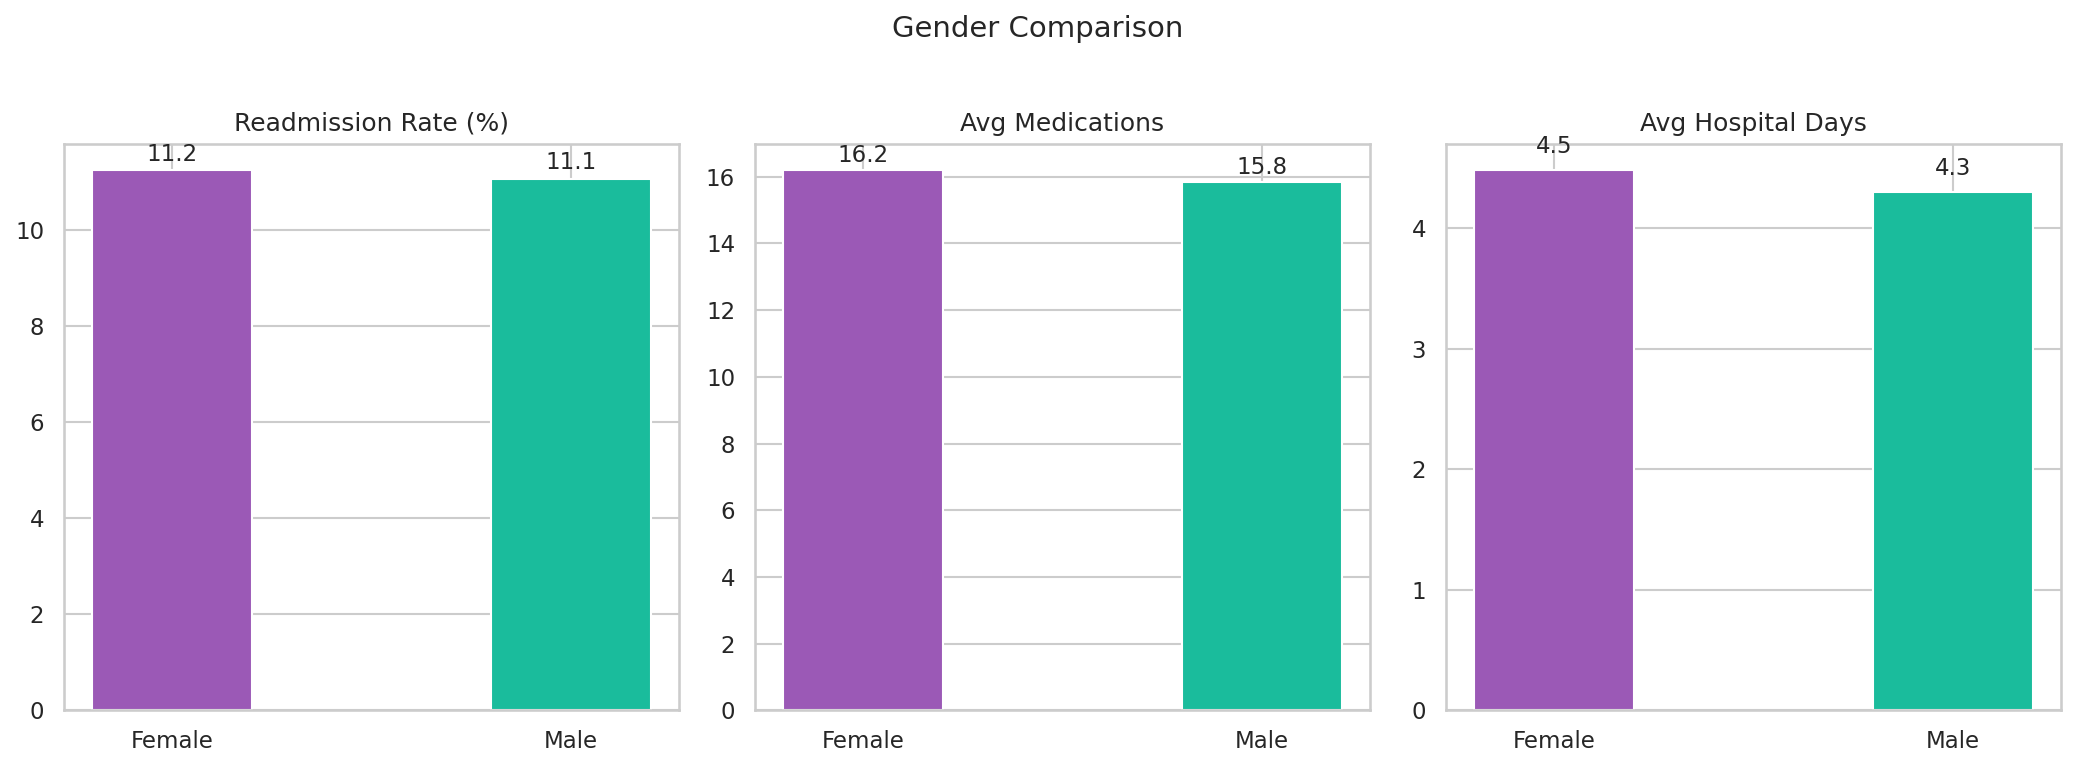

In [ ]:
gender_df = df[df['gender'].isin(['Male', 'Female'])]
gender_stats = gender_df.groupby('gender').agg(
    readmission_rate=('readmitted_binary', lambda x: x.mean() * 100),
    avg_medications=('num_medications', 'mean'),
    avg_hospital_days=('time_in_hospital', 'mean')
).round(2)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#9b59b6', '#1abc9c']
metrics = ['readmission_rate', 'avg_medications', 'avg_hospital_days']
titles = ['Readmission Rate (%)', 'Avg Medications', 'Avg Hospital Days']

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(gender_stats.index, gender_stats[metric],
                  color=colors, edgecolor='white', width=0.4)
    ax.set_title(title, fontsize=12)
    for bar, val in zip(bars, gender_stats[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=11)

plt.suptitle('Gender Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('chart6_gender.png', bbox_inches='tight')
plt.show()

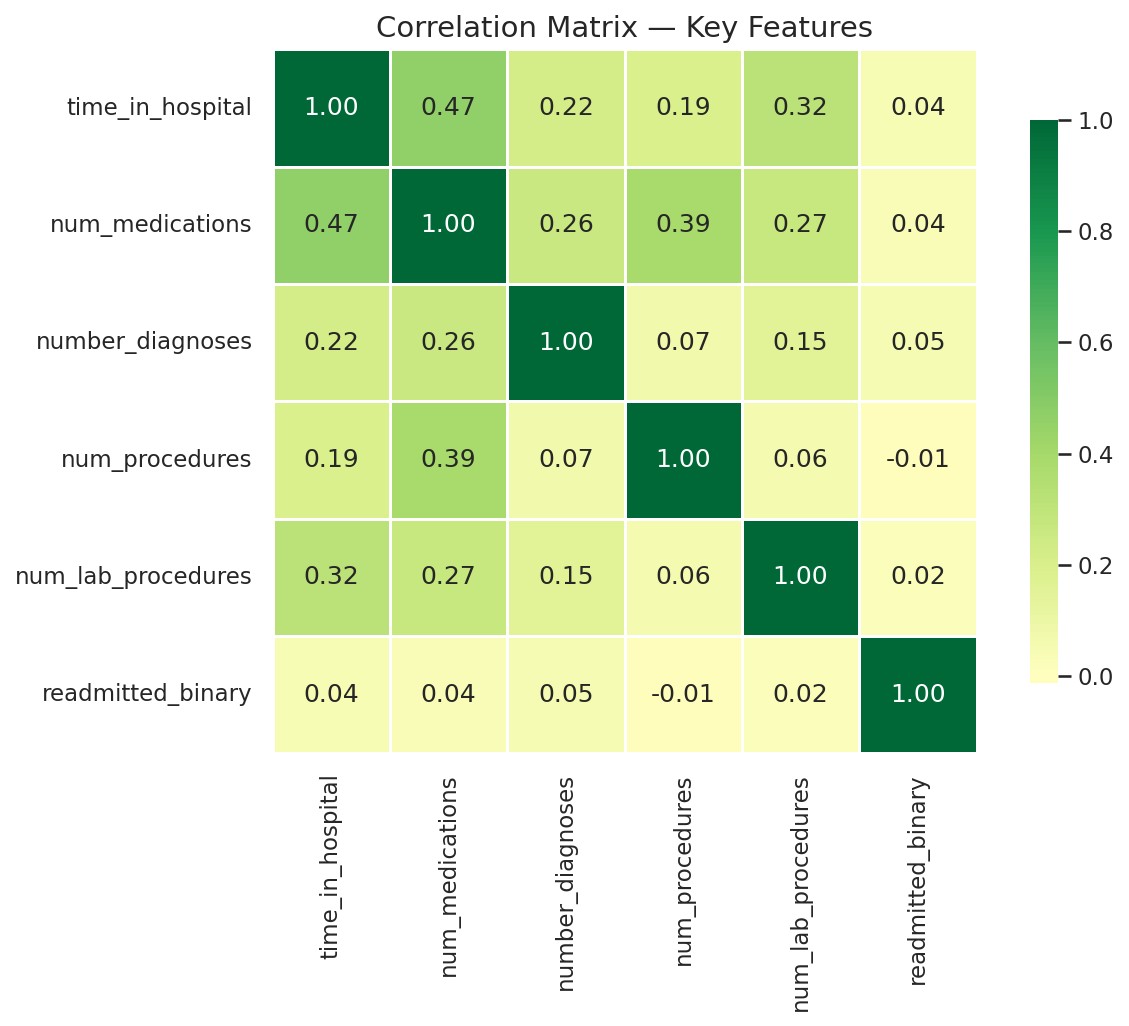

In [ ]:
numeric_cols = ['time_in_hospital', 'num_medications', 'number_diagnoses',
                'num_procedures', 'num_lab_procedures', 'readmitted_binary']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix — Key Features', fontsize=14)
plt.tight_layout()
plt.savefig('chart7_correlation.png', bbox_inches='tight')
plt.show()

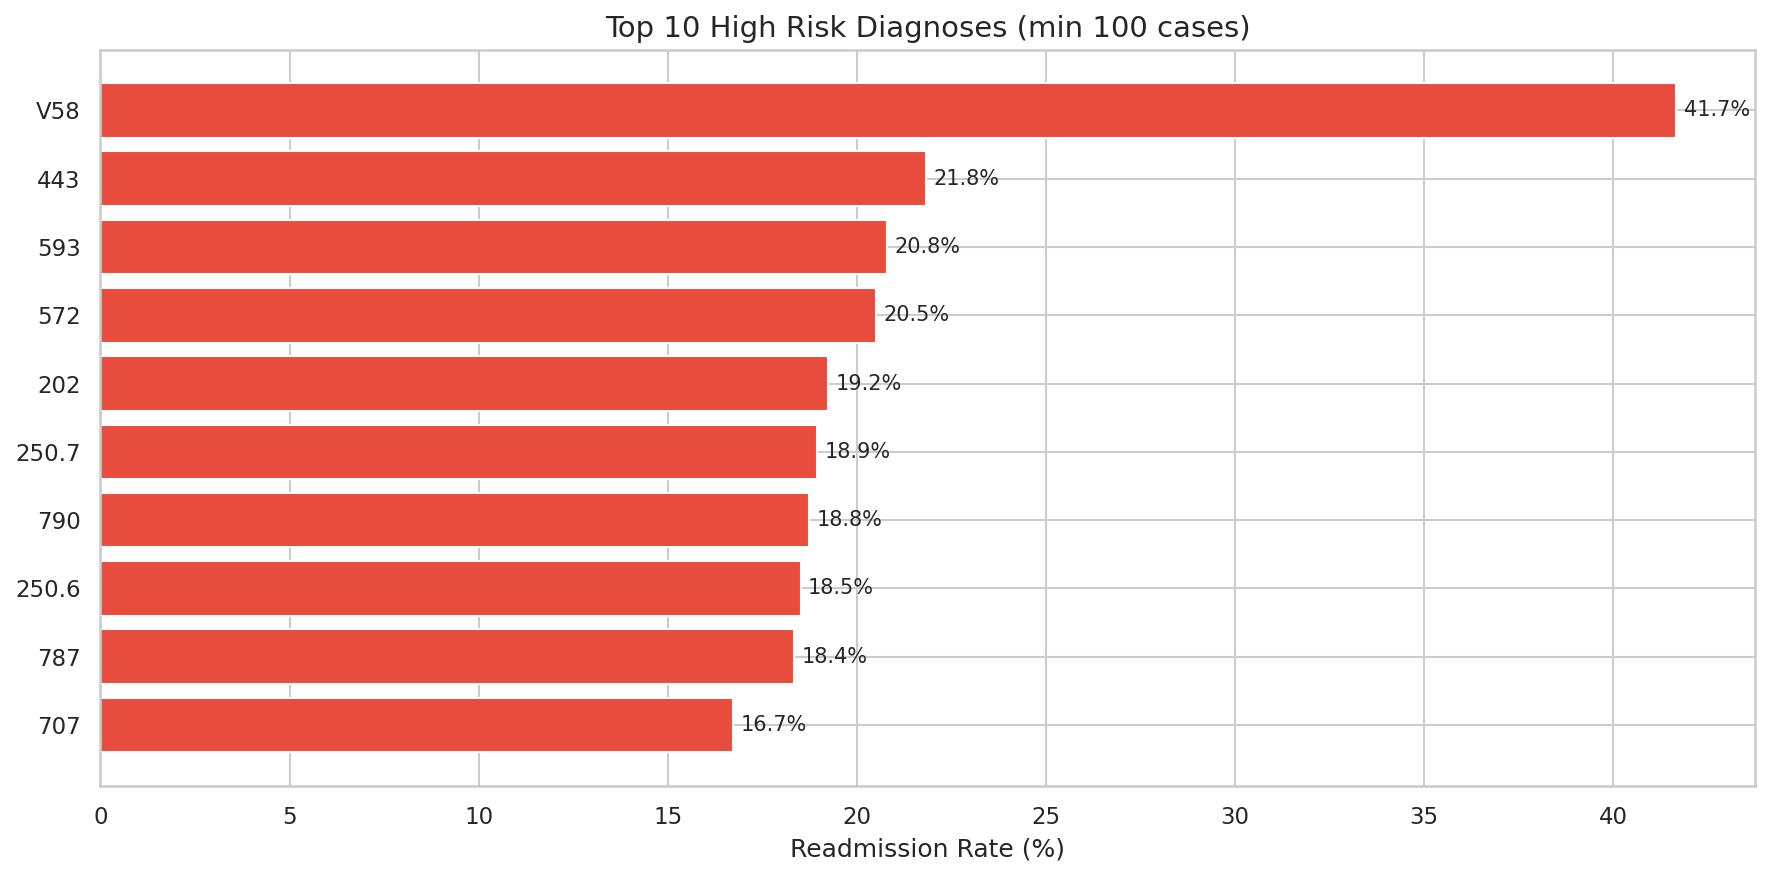

In [ ]:
diag_stats = df.groupby('diag_1').agg(
    total=('readmitted_binary', 'count'),
    readmission_rate=('readmitted_binary', lambda x: x.mean() * 100)
).query('total > 100').sort_values('readmission_rate', ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(diag_stats.index[::-1],
                diag_stats['readmission_rate'][::-1],
                color='#e74c3c', edgecolor='white')

plt.title('Top 10 High Risk Diagnoses (min 100 cases)', fontsize=14)
plt.xlabel('Readmission Rate (%)')

for bar, val in zip(bars, diag_stats['readmission_rate'][::-1]):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart8_diagnoses.png', bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('hospital_readmission_clean.csv', low_memory=False)

# Ye columns model mein use honge
feature_cols = [
    'age', 'gender', 'race',
    'time_in_hospital', 'num_medications',
    'number_diagnoses', 'num_procedures',
    'num_lab_procedures', 'medical_specialty',
    'admission_type_id', 'discharge_disposition_id'
]

X = df[feature_cols].copy()
y = df['readmitted_binary'].copy()

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features shape: (101745, 11)
Target distribution:
readmitted_binary
0    90393
1    11352
Name: count, dtype: int64


In [ ]:
df = pd.read_csv('hospital_readmission_clean.csv')
df

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_binary
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,Steady,No,No,No,No,No,Ch,Yes,NO,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101740,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,Unknown,...,Down,No,No,No,No,No,Ch,Yes,>30,0
101741,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,Unknown,...,Steady,No,No,No,No,No,No,Yes,NO,0
101742,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,Unknown,...,Down,No,No,No,No,No,Ch,Yes,NO,0
101743,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,Surgery-General,...,Up,No,No,No,No,No,Ch,Yes,NO,0


In [ ]:
le = LabelEncoder()

text_columns = ['age', 'gender', 'race', 'medical_specialty']

for col in text_columns:
    X[col] = le.fit_transform(X[col].astype(str))

print("Encoding complete!")
print(X.dtypes)

Encoding complete!
age                         int64
gender                      int64
race                        int64
time_in_hospital            int64
num_medications             int64
number_diagnoses            int64
num_procedures              int64
num_lab_procedures          int64
medical_specialty           int64
admission_type_id           int64
discharge_disposition_id    int64
dtype: object


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training rows:   {len(X_train)}")
print(f"Testing rows:    {len(X_test)}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())

Training rows:   81396
Testing rows:    20349

Training target distribution:
readmitted_binary
0    72314
1     9082
Name: count, dtype: int64


In [ ]:
nr= (y_train == 0).sum()
ra= (y_train == 1).sum()
scale = nr/ ra

print(f"Class 0 (not readmitted): {nr}")
print(f"Class 1 (readmitted):     {ra}")
print(f"Scale weight:             {scale:.2f}")

Class 0 (not readmitted): 72314
Class 1 (readmitted):     9082
Scale weight:             7.96


In [ ]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"Total predictions: {len(y_pred)}")
print(f"Predicted readmitted: {y_pred.sum()}")
print(f"Predicted not readmitted: {(y_pred == 0).sum()}")

Total predictions: 20349
Predicted readmitted: 8835
Predicted not readmitted: 11514


In [ ]:
print("=" * 45)
print("        MODEL PERFORMANCE REPORT")
print("=" * 45)
print(f"Accuracy:   {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision:  {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall:     {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score:   {f1_score(y_test, y_pred)*100:.2f}%")
print(f"ROC-AUC:    {roc_auc_score(y_test, y_pred_proba)*100:.2f}%")
print("=" * 45)
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

        MODEL PERFORMANCE REPORT
Accuracy:   58.82%
Precision:  15.43%
Recall:     60.04%
F1 Score:   24.55%
ROC-AUC:    63.12%

Detailed Report:
              precision    recall  f1-score   support

           0       0.92      0.59      0.72     18079
           1       0.15      0.60      0.25      2270

    accuracy                           0.59     20349
   macro avg       0.54      0.59      0.48     20349
weighted avg       0.84      0.59      0.66     20349



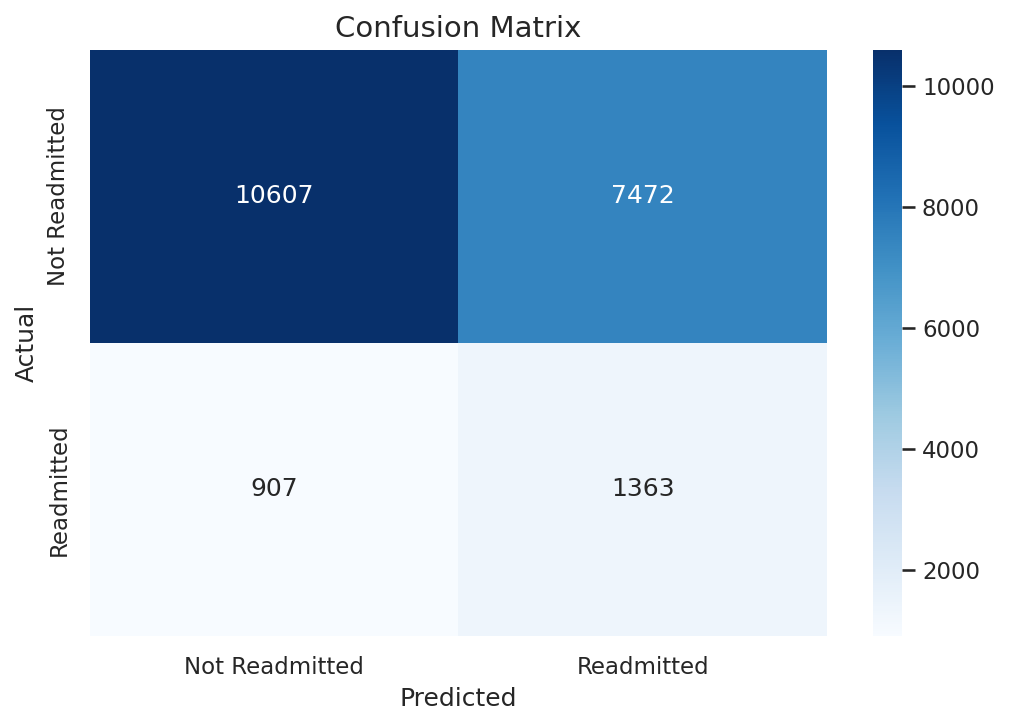

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('chart9_confusion_matrix.png', bbox_inches='tight')
plt.show()

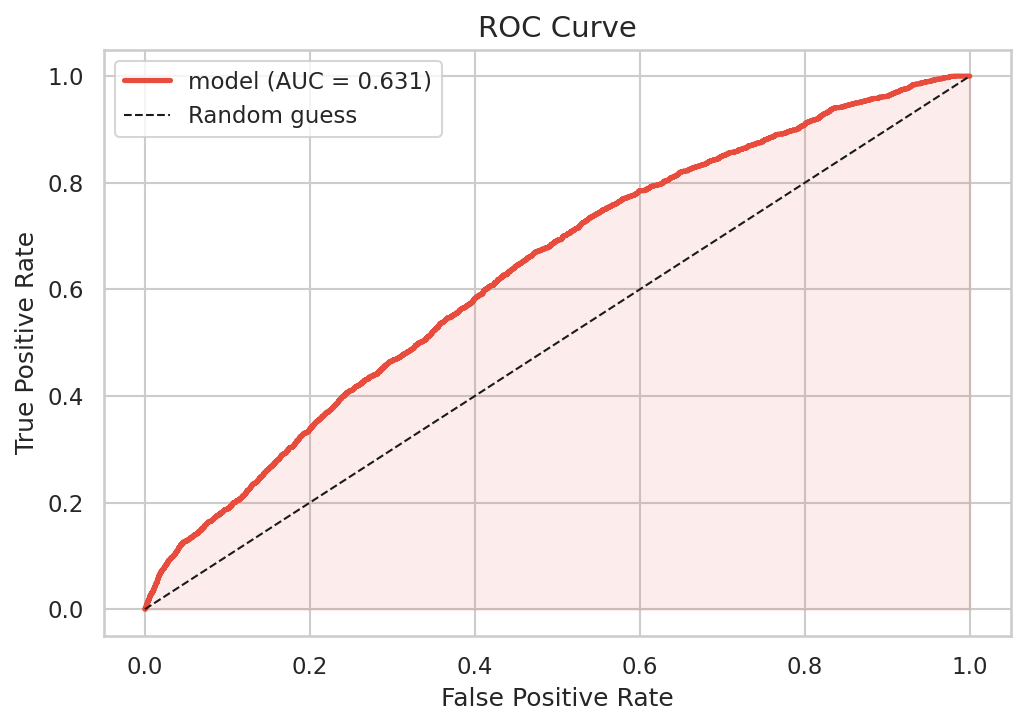

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
         label=f'model (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Random guess')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('chart10_roc_curve.png', bbox_inches='tight')
plt.show()

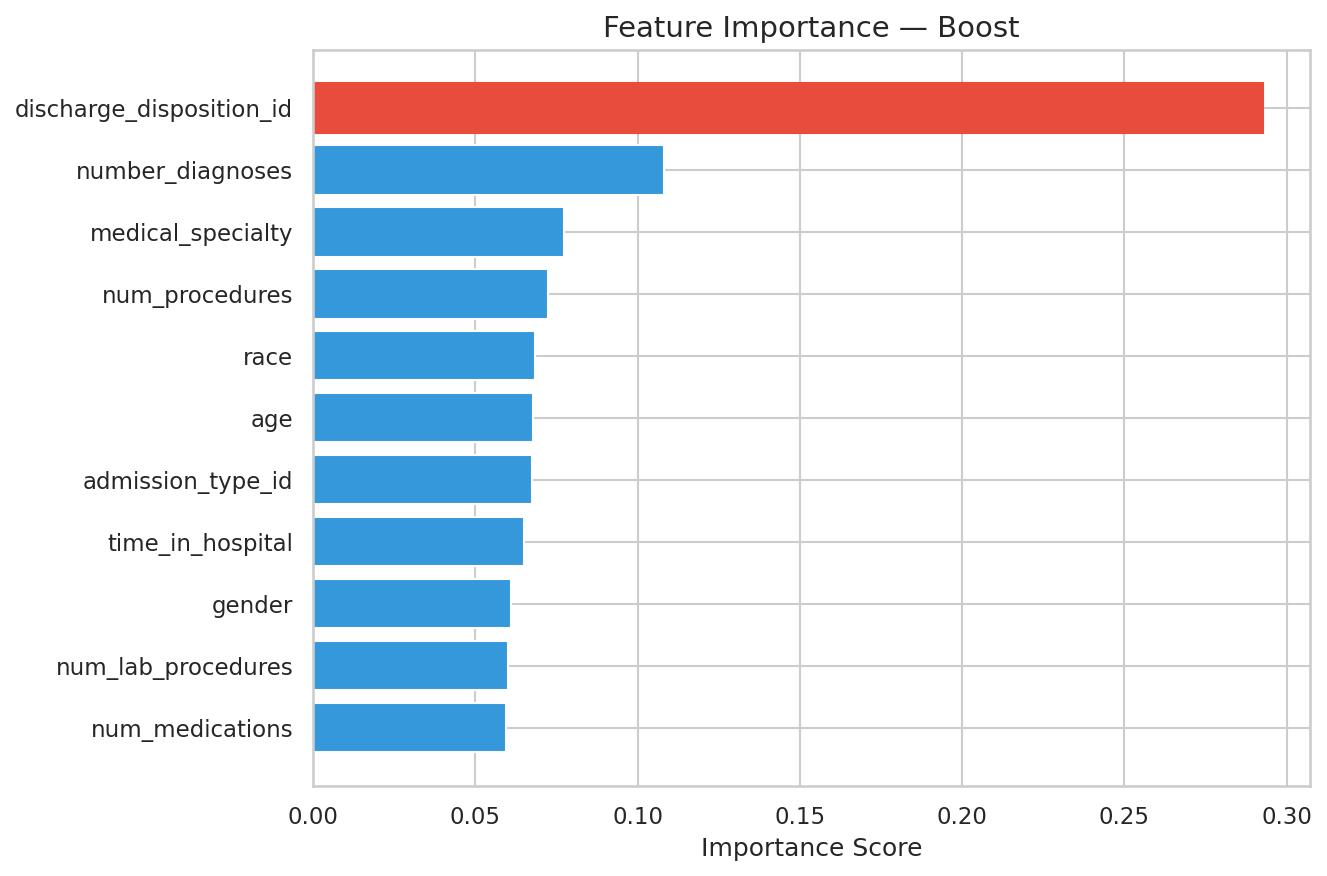

In [ ]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 6))
bars = plt.barh(importance_df['feature'],
                importance_df['importance'],
                color='#3498db', edgecolor='white')

bars[-1].set_color('#e74c3c')

plt.title('Feature Importance — Boost', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('chart11_feature_importance.png', bbox_inches='tight')
plt.show()

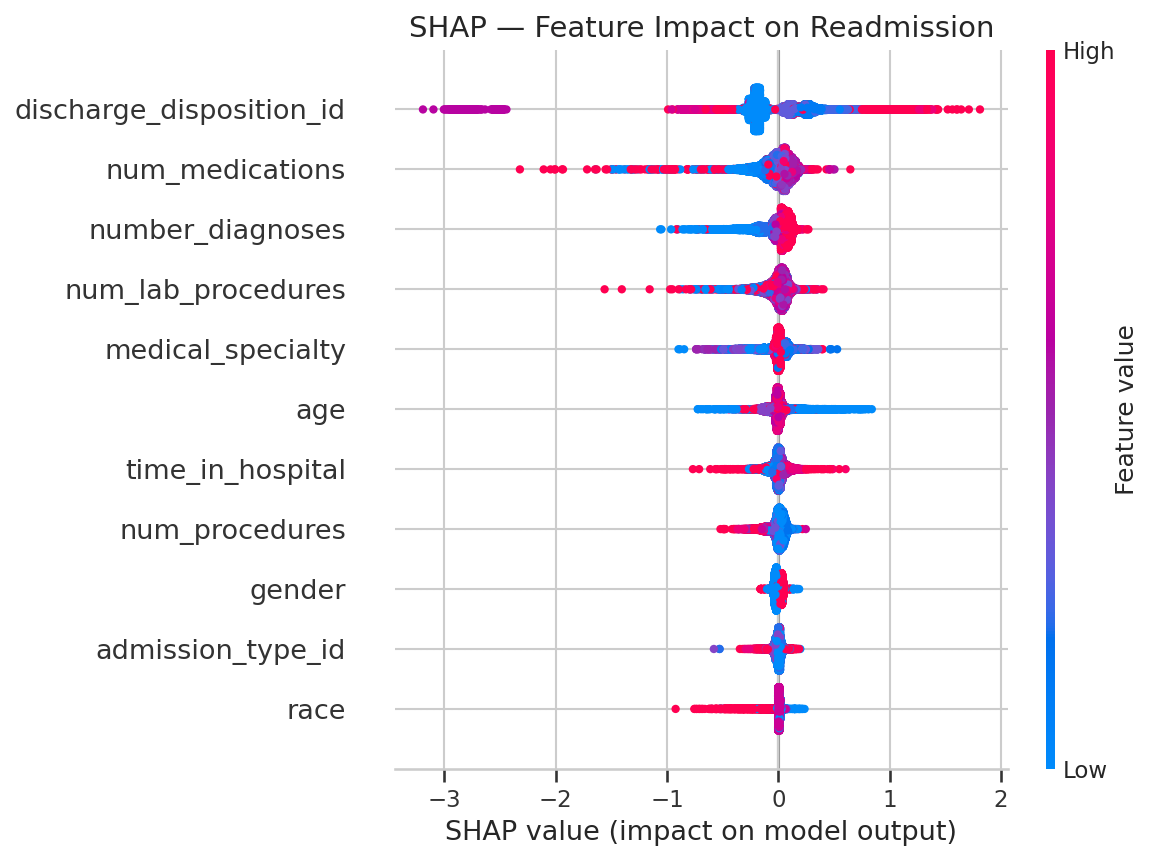

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  show=False)
plt.title('SHAP — Feature Impact on Readmission', fontsize=14)
plt.tight_layout()
plt.savefig('chart12_shap_summary.png', bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

insights = {
    'Finding': [
        'Overall Readmission Rate',
        'Highest Risk Age Group',
        'Most Dangerous Diagnosis',
        'Medications vs Readmission',
        'Hospital Stay vs Readmission',
        'Most Important ML Feature',
        'Model Performance (Recall)',
        'High Risk Patients Identified'
    ],
    'Insight': [
        '11.16% patients 30 din mein wapas aate hain',
        '20-30 age group mein 14.25% readmission — sabse zyada',
        'V58 (Follow-up care) mein 41.7% readmission rate',
        '16+ medicines wale patients mein 12.48% readmission — 1-5 medicines se 67% zyada',
        '8-10 din hospital mein rehne wale patients mein peak readmission (14%+)',
        'Discharge destination sabse important predictor — kahan discharge hua',
        'Model ne 60% actual readmissions pakde',
        '20 high-risk patients identified — 80+ medications, 7+ hospital days'
    ],
    'Business Recommendation': [
        'Hospital readmission reduction program banana chahiye',
        '20-30 age group ke liye special follow-up protocol banana chahiye',
        'V58 patients ke liye discharge ke baad 48 ghante mein call back system lagao',
        '15+ medicines wale patients ke liye medication review mandatory karo',
        '7+ din wale patients ke liye post-discharge monitoring program shuru karo',
        'Discharge planning team ko strengthen karo — nursing facility patients pe focus',
        'High recall model use karo — miss hone se better hai false alarm',
        'In 20 patients ko priority follow-up do — readmission risk highest hai'
    ],
    'Data Source': [
        'SQL Query 1',
        'SQL Query 2 + EDA Chart 2',
        'SQL Query 3 + EDA Chart 8',
        'SQL Query 5 + EDA Chart 4',
        'SQL Query 6 + EDA Chart 3',
        'ML Feature Importance + SHAP',
        'ML Model Performance Report',
        'SQL Query 8'
    ]
}

df_insights = pd.DataFrame(insights)

df_insights.to_excel('Project1_Insights_Report.xlsx', index=False)


In [ ]:
# Step 1 — Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

# Step 2 — Data load
df = pd.read_csv('hospital_readmission_clean.csv', low_memory=False)

feature_cols = [
    'age', 'gender', 'race',
    'time_in_hospital', 'num_medications',
    'number_diagnoses', 'num_procedures',
    'num_lab_procedures', 'medical_specialty',
    'admission_type_id', 'discharge_disposition_id'
]

X = df[feature_cols].copy()
y = df['readmitted_binary'].copy()

# Step 3 — Encoding
le = LabelEncoder()
for col in ['age', 'gender', 'race', 'medical_specialty']:
    X[col] = le.fit_transform(X[col].astype(str))

# Step 4 — Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Step 5 — Scale
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

# Step 6 — Train
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train, y_train)

# Save
with open('readmission_model.pkl', 'wb') as f:
    pickle.dump(model, f)
